# ¡Hola Luis! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v2 </b> <a class="tocSkip"></a>

Bien hecho Luis, buen trabajo con las últimas correcciones. Has terminado completamente las tareas necesarias del notebook, no tengo comentarios de corrección adicionales, tu proyecto está aprobado. Los conocimientos que aplicaste aquí te serán muy útiles para análisis futuros, mucho éxito!

Saludos!

</div>

----

# Inicialización - Estudiar datos.

In [1]:
#Librerias a utilizar
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from math import factorial
from scipy import stats as st
import math as mt

In [2]:
#Cargar el Dataframe a analizar
juegos = pd.read_csv("/datasets/games.csv")

In [3]:
#Revisar los datos del DataFrame
juegos.info()
juegos.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
#Pasar los titulos de las columnas a minusculas para un mejor control
juegos.columns = juegos.columns.str.lower()

In [5]:
#Cambiar los tipos de columna incorrectos y datos ausentes de las columnas
juegos["year_of_release"] = pd.to_numeric(juegos["year_of_release"], errors="coerce").astype("Int64")
juegos["user_score_num"] = pd.to_numeric(juegos["user_score"], errors="coerce").astype("float64")

In [6]:
#Cambiar los valores ausentes para un mejor analisis
for col in ["name", "genre", "rating"]:
    juegos[col] = juegos[col].fillna("unknown")
juegos.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_num
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,8.0
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,8.3
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,8.0
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,NaN


Análisis de la primera parte.

Al utilizar el método info(), observamos que varias columnas contienen datos ausentes. En algunos casos, la cantidad de valores faltantes es tan elevada que dificulta su uso para el análisis, por lo que no resulta conveniente apoyarse en esas columnas para obtener conclusiones.

Las columnas "year_of_release" y "user_score" tenían tipos de datos incorrectos. En el caso de "year_of_release", realizamos la conversión sin problema. Sin embargo, "user_score" contiene valores numéricos, valores ausentes y además el valor especial "TBD", que se interpreta como valor ausente. Debido a esta mezcla de formatos, no convertimos directamente la columna original; en su lugar, creamos una nueva columna numérica limpia, que facilita el análisis sin perder la información textual original.

Igual critic_score, tiene muchos valores ausente, lo cual puede provocar analisis inconclusos.

Para los valores ausentes en las columnas "name", "genre" y "rating", los reemplazamos por "unknown". Esto permite identificar fácilmente los registros incompletos sin eliminar datos ni introducir confusión durante el análisis.

En cuanto al origen de los valores ausentes, es probable que muchos correspondan a juegos muy antiguos, publicados en años en los que no era común contar con críticas o publicaciones en múltiples regiones.


<div class="alert alert-block alert-success">
<b>Comentario de Revisor    v2      </b> <a class="tocSkip"></a>

Bien hecho. En los casos donde hay demasiados en una columna, me parece bien dejar los nulos tal como están o reemplazarlos por algún valor identificable. En este caso, no hay data suficiente para hacer una imputación adecuada y en caso de rellenar con la media o mediana, se introduce un sesgo muy fuerte en la data, por lo que no es adecuado.



</div>

In [7]:
#Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego.
juegos["total_sales"] = juegos["na_sales"] + juegos["eu_sales"] + juegos ["jp_sales"] + juegos["other_sales"]
juegos.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_num,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,8.0,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,8.3,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,8.0,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,NaN,31.38


# Analiza los datos

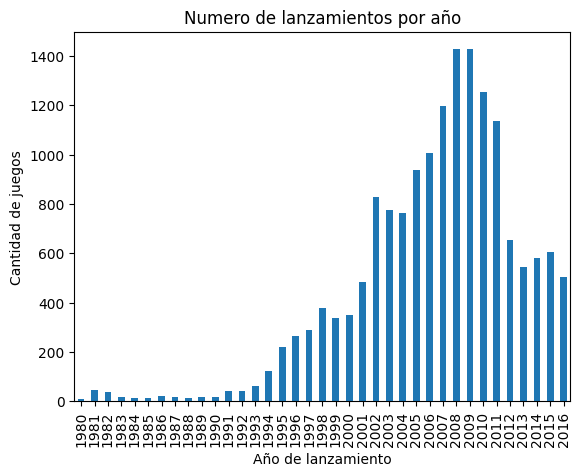

In [8]:
#Cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?
year_release = juegos["year_of_release"].value_counts().sort_index()
year_release.plot(xlabel="Año de lanzamiento",
                  ylabel="Cantidad de juegos",
                  title="Numero de lanzamientos por año",
                     kind="bar"
                     )
plt.show()

Al inicio del periodo analizado, la cantidad de lanzamientos de videojuegos era muy baja. Esto se debe a que la industria aún no era tan conocida y existían importantes limitaciones tecnológicas.

Entre 1995 y 2009, se observa un crecimiento notable en el número de lanzamientos. Durante estos años aparecieron consolas como PlayStation, Xbox y nuevas generaciones de Nintendo, acompañadas de videojuegos exclusivos para cada plataforma. Esto impulsó significativamente el mercado y generó un auténtico crecimiento explosivo en la industria.

A partir de 2010, el número de lanzamientos comienza a disminuir ligeramente. Sin embargo, esta disminución no representa una caída grave, sino más bien un cambio en el enfoque de los desarrolladores. En esta etapa, la industria empezó a priorizar la calidad sobre la cantidad, lo que provocó que los tiempos de producción se alargaran y, en consecuencia, que los lanzamientos anuales fueran menos numerosos.

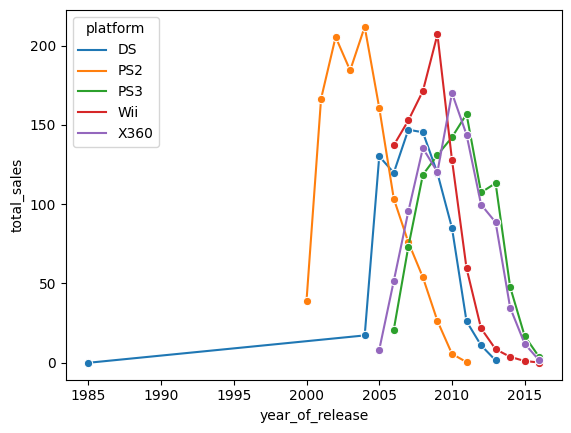

In [9]:
#Revisar cada plataforma para analizar ¿cuales plataformas tienen mayores venta?
platform_sales = juegos.groupby(["platform", "year_of_release"])["total_sales"].sum().reset_index()
top_platforms = juegos.groupby("platform")["total_sales"].sum().sort_values(ascending=False).head(5)
filtered = platform_sales[platform_sales["platform"].isin(top_platforms.index)]

#Grafico para mostrar los resultados
sns.lineplot(
    data=filtered,
    x="year_of_release",
    y="total_sales",
    hue="platform",
    marker="o"
)
plt.show()

Busca las plataformas que solían ser populares pero que ahora no tienen ventas.¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

El análisis muestra que plataformas como DS, PS2, PSP3, Xbox 360 y Wii tuvieron un gran volumen de ventas en su momento, pero actualmente ya no registran ventas.

Esto refleja el ciclo de vida típico de una consola:
Aparecen con ,

*   Ventas moderadas.
*   Alcanzan un pico cuando la plataforma está en su máximo nivel de adopción.
*   Finalmente desaparecen cuando son reemplazadas por nuevas generaciones tecnológicas.


<div class="alert alert-block alert-success">
<b>Comentario de Revisor     v2     </b> <a class="tocSkip"></a>

Correcto, muy bien con los gráficos



</div>

Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

Para construir el modelo de predicción para 2017, es adecuado utilizar los datos desde 2000 hasta 2016.
En este período se observa el ciclo moderno de las plataformas: aparición, crecimiento, pico de ventas y declive.
Los datos previos al 2000 son escasos y pertenecen a una etapa tecnológica distinta, por lo que no aportan información útil al modelo.
Usar 2000–2016 permite capturar tendencias recientes y completas, necesarias para predecir adecuadamente el comportamiento esperado en 2017.

In [10]:
#Plataformas recientes mas rentables
recent_years = juegos[juegos["year_of_release"] >= 2015]
recent_platforms = recent_years.groupby("platform")["total_sales"].sum().sort_values(ascending=False).reset_index().head(5)
print("Plataformas potencialmente rentables:")
print(recent_platforms)

Plataformas potencialmente rentables:
  platform  total_sales
0      PS4       188.15
1     XOne        86.29
2      3DS        42.92
3     WiiU        20.95
4      PS3        20.42


¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

A partir del análisis previo, las plataformas líderes en ventas históricas fueron PS2, Wii y Xbox 360, que alcanzaron los mayores volúmenes de ventas durante sus ciclos de vida. Sin embargo, estas plataformas ya no registran ventas en los años recientes debido a que fueron descontinuadas y reemplazadas por nuevas generaciones de consolas.

Al enfocarnos en los datos más recientes,principalmente a partir de 2015, que es el último año con información completo, para poder estudiar que plataformas estan en crecimiento que son PS4, PS3, XBOX One, 3DS, XBOX360. Estas consolas siguen registrando ventas y muestran una tendencia estable o ligeramente creciente, lo cual las convierte en plataformas potencialmente rentables para seguir publicando videojuegos o invertir en su catálogo.

Por otro lado, algunas plataformas todavía registran ventas en 2015, pero ya muestran señales claras de declive, como PS3 o Xbox 360. En estos casos, sus ventas restantes probablemente se deban a ediciones especiales, coleccionistas o liquidación de inventarios, pero no representan un crecimiento real.


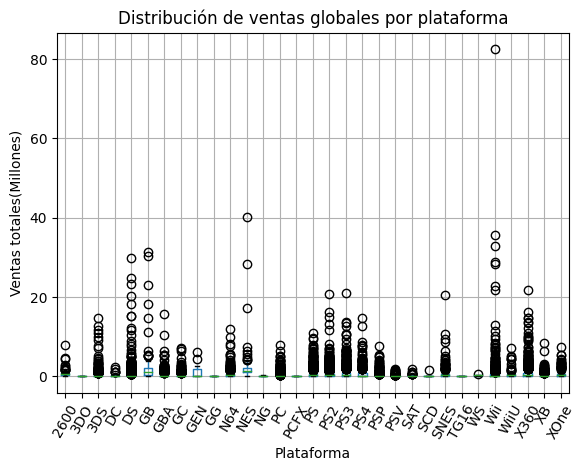

<Figure size 1600x800 with 0 Axes>

In [11]:
#Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma.
Ventas = juegos[['platform', 'total_sales']]

Ventas.boxplot(column="total_sales", by="platform")
plt.title("Distribución de ventas globales por plataforma")
plt.suptitle("")
plt.xlabel("Plataforma")
plt.ylabel("Ventas totales(Millones)")
plt.xticks(rotation=60)
plt.figure(figsize=(16,8))
plt.show()

¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas?

Las diferencias en las ventas entre plataformas son claramente significativas. Algunas consolas, como Wii, PS2 o Xbox 360, presentan ventas promedio considerablemente superiores, además de una alta variabilidad, lo que indica la existencia de títulos extremadamente exitosos.

Por el contrario, plataformas con menor presencia en el mercado —como PCFX, GG o WS— muestran tanto ventas totales como promedios muy bajos, con poca variación entre sus juegos.

Esto confirma que el rendimiento comercial difiere ampliamente entre plataformas y que solo algunas concentraron la mayor parte del mercado.


In [12]:
# Revisar las reseñas profesionales y de usuarios para XBOX360 y la correlacion entre reseñas y ventas
platform_to_review = juegos[juegos["platform"] == "X360"]
review = platform_to_review[["user_score_num", "critic_score", "total_sales"]]
review_final = review.corr()
print (review_final)

                user_score_num  critic_score  total_sales
user_score_num        1.000000      0.618101     0.114459
critic_score          0.618101      1.000000     0.393736
total_sales           0.114459      0.393736     1.000000


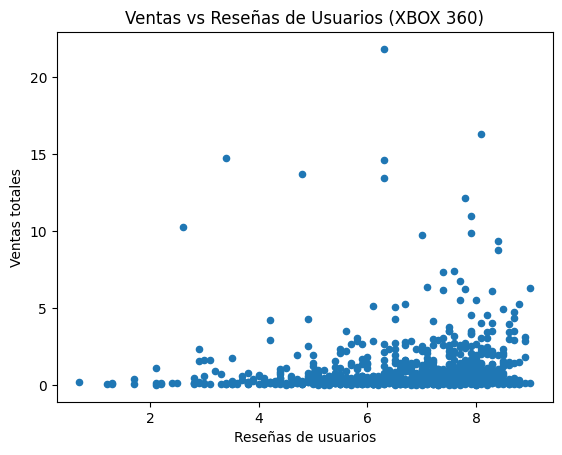

In [13]:
#Grafico de dispersion de reseñas de Usuario
review.plot.scatter(x="user_score_num", y="total_sales", title="Ventas vs Reseñas de Usuarios (XBOX 360)")
plt.xlabel("Reseñas de usuarios")
plt.ylabel("Ventas totales")
plt.show()

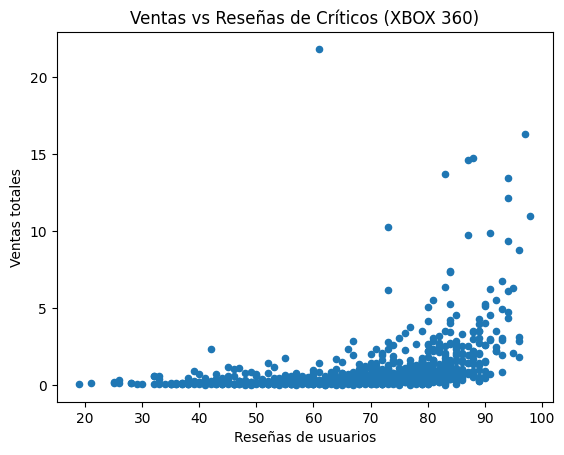

In [14]:
#Grafico de dispersion de reseñas de criticas
review.plot.scatter(x="critic_score", y="total_sales", title="Ventas vs Reseñas de Críticos (XBOX 360)")
plt.xlabel("Reseñas de usuarios")
plt.ylabel("Ventas totales")
plt.show()

Conclusiones.

Al analizar la plataforma de XBOX 360, las reseñas de usuarios y de críticos muestran un impacto medible en las ventas, pero no con la misma intensidad. Las calificaciones de críticos presentan una correlación más fuerte con las ventas totales, lo que indica que las evaluaciones profesionales influyen más en el rendimiento comercial de los juegos de esta plataforma.

Por otro lado, la correlación con las reseñas de usuarios es más baja, lo que sugiere que, aunque importan, no determinan de forma tan clara el éxito en ventas y igualmente recordar que esta columna tenia muchos datos ausentes lo cual tambien nos lleva a sacar esta conclusion.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, bien con el cálculo del coeficiente de correlación y los gráficos.


</div>

In [15]:
# Comparacion de los juegos de XBOX 360 vs las demas plataformas
x360_games = juegos[juegos["platform"] == "X360"]["name"].unique()
same_games = juegos[juegos["name"].isin(x360_games)]

#Agrupar ventas por juego y plataforma
comparison = (same_games.groupby(["name", "platform"])["total_sales"].sum().reset_index().sort_values(by=["name", "total_sales"], ascending=[True, False]))
print(comparison.head(22))


                                                 name platform  total_sales
5                              007: Quantum of Solace     X360         1.48
3                              007: Quantum of Solace      PS3         1.15
4                              007: Quantum of Solace      Wii         0.65
2                              007: Quantum of Solace      PS2         0.43
0                              007: Quantum of Solace       DS         0.13
1                              007: Quantum of Solace       PC         0.02
6                                   11eyes: CrossOver      PSP         0.02
7                                   11eyes: CrossOver     X360         0.02
9   2 in 1 Combo Pack: Sonic Heroes / Super Monkey...       XB         0.53
8   2 in 1 Combo Pack: Sonic Heroes / Super Monkey...     X360         0.11
10                   2010 FIFA World Cup South Africa      PS3         1.23
13                   2010 FIFA World Cup South Africa     X360         0.85
11          

Conclusion.

Como se observa en la comparación, varios juegos multiplataforma registran mayores ventas en consolas distintas a Xbox 360, especialmente en PS3, que muestran un desempeño superior. Esto indica que dichas plataformas resultan más rentables en términos de mercado.

Las diferencias pueden explicarse por factores como lanzamientos exclusivos que atraen más jugadores hacia ciertas consolas, precios ofrecidos, etc.

Sin embargo, esta información debe interpretarse únicamente como una comparación histórica, ya que la consola Xbox 360 fue reemplazada por versiones más recientes, lo que limita su relevancia para decisiones futuras.


genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
unknown            2.42
Name: total_sales, dtype: float64


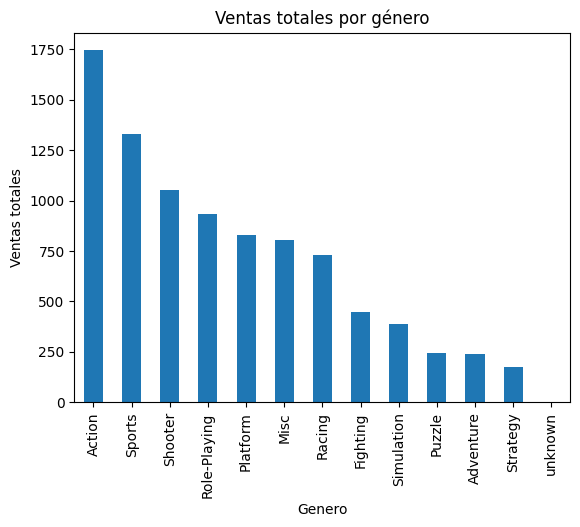

In [16]:
#Distribucion general de los juegos por genero.
genre_sales = (juegos.groupby("genre")["total_sales"].sum().sort_values(ascending=False))
print (genre_sales)

#Grafica de lo obtenido anteriormente
genre_sales.plot(xlabel="Genero",
                 ylabel="Ventas totales",
                 title="Ventas totales por género",
                 kind="bar",
                 )

plt.show()

¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

Los géneros más rentables son Acción, Shooter y Deportes, que dominan el mercado gracias a franquicias globales y lanzamientos recurrentes. En contraste, Puzzle, Estrategia, Adventure y Simulación muestran ventas bajas y se consideran géneros de nicho, dirigidos principalmente a los fans del género.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Ok con la venta total, pero en realidad lo mejor sería combinar esto con la venta promedio. Es importante ver si hay géneros que con pocos juegos hacen grandes ventas.



</div>

# Analisis de cada region

In [17]:
# Agrupar ventas por plataforma en cada región
ventas_por_region = juegos.groupby("platform")[["na_sales", "eu_sales", "jp_sales"]].sum()

#Las 5 plataformas principales de cada region
top_na = ventas_por_region["na_sales"].sort_values(ascending=False).head(5)
top_eu = ventas_por_region["eu_sales"].sort_values(ascending=False).head(5)
top_jp = ventas_por_region["jp_sales"].sort_values(ascending=False).head(5)

print("Top 5 plataformas en NA:\n", top_na)
print("\nTop 5 plataformas en EU:\n", top_eu)
print("\nTop 5 plataformas en JP:\n", top_jp)

Top 5 plataformas en NA:
 platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas en EU:
 platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas en JP:
 platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


Las cuotas de mercado varían significativamente por región: Xbox domina en Norteamérica y Europa, pero tiene presencia nula en Japón. Nintendo, en cambio, lidera en Japón con DS, SNES y 3DS. Sony mantiene una posición fuerte y constante en todas las regiones, especialmente con PS2 y PS3

In [18]:
# Agrupar ventas por genero en cada región
generos_por_region = juegos.groupby("genre")[["na_sales", "eu_sales", "jp_sales"]].sum()

#Las 5 generos principales de cada region
top_genre_na = generos_por_region["na_sales"].sort_values(ascending=False).head(5)
top_genre_eu = generos_por_region["eu_sales"].sort_values(ascending=False).head(5)
top_genre_jp = generos_por_region["jp_sales"].sort_values(ascending=False).head(5)

print("Top 5 generos en NA:\n", top_genre_na)
print("\nTop 5 genros en EU:\n", top_genre_eu)
print("\nTop 5 generos en JP:\n", top_genre_jp)

Top 5 generos en NA:
 genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 genros en EU:
 genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 generos en JP:
 genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


En las tres regiones algunos generos como Accion y Deportes estan presentes tal y como habiamos visto antes. Estas diferencias no solo reflejan los gustos culturales, sino el impacto de franquicias locales y populares, al igual el estilo de juegos tradicionales en cada region

Una comparacion simple es que en NA el atractivo son los Shooters juegos que su cometido es dar una experencia de acción rápida y competitiva mientras que en Japon el gusto es por juegos con experiencias más profundas, narrativas y prolongadas.

In [19]:
#Analizando si las clasificacion afectan a las ventas en regiones individuales
clasificacion_sales = (juegos.groupby("rating")[["na_sales", "eu_sales", "jp_sales"]].sum())

#Clasificacion por cada region
rating_genre_na = clasificacion_sales["na_sales"].sort_values(ascending=False)
rating_genre_eu = clasificacion_sales["eu_sales"].sort_values(ascending=False)
rating_genre_jp = clasificacion_sales["jp_sales"].sort_values(ascending=False)

print("Rating en NA:\n", rating_genre_na)
print("\nRating en EU:\n", rating_genre_eu)
print("\nRating en JP:\n", rating_genre_jp)


Rating en NA:
 rating
E          1292.99
unknown    1242.46
T           759.75
M           748.48
E10+        353.32
K-A           2.56
EC            1.53
AO            1.26
RP            0.00
Name: na_sales, dtype: float64

Rating en EU:
 rating
E          710.25
unknown    613.83
M          483.97
T          427.03
E10+       188.52
AO           0.61
K-A          0.27
EC           0.11
RP           0.08
Name: eu_sales, dtype: float64

Rating en JP:
 rating
unknown    841.96
E          198.11
T          151.40
M           64.24
E10+        40.20
K-A          1.46
AO           0.00
EC           0.00
RP           0.00
Name: jp_sales, dtype: float64


¿Las clasificaciones ESRB afectan a las ventas en regiones individuales?

Sí, las clasificaciones ESRB afectan las ventas por región:
NA y EU, prefieren juegos T y M, con contenido más maduro.
JP, prefiere juegos E y T, menos orientados a contenido explícito.

Esto demuestra que las preferencias culturales influyen directamente en cómo la clasificación ESRB impacta las ventas.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

# Pruebas de hipotesis

In [20]:
#Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
#Filtrar por plataforma
xone_scores = juegos.loc[juegos["platform"] == "XOne", "user_score_num"].dropna()
pc_scores = juegos.loc[juegos["platform"] == "PC", "user_score_num"].dropna()

#Se establece alpha en 0.05
alpha = 0.05

#Se usa una prueba de dos muestras diferentes
results = st.ttest_ind(xone_scores, pc_scores)
print("valor p", results.pvalue)

#Resultado
if results.pvalue < alpha:
  print("Rechazamos la hipotesis")
else:
  print("No podemos rechazar la hipotesis nula")


valor p 1.3896435533548819e-05
Rechazamos la hipotesis


Conclusion de la hipotesis.

Con un valor p de aproximadamente 0.0000139, que es significativamente menor que el umbral alfa de 0.05, se rechaza la hipótesis nula. Esto indica que existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios para las plataformas Xbox One y PC. Por lo tanto, no se puede asumir que ambas plataformas reciben la misma valoración por parte de los usuarios.

Con una prueba de dos muestras, podemos determinar si existen diferencias significativas en la percepción de los usuarios entre ambas plataformas.

In [21]:
#Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
#Filtrar calificacion por genero
accion_scores = juegos.loc[juegos["genre"] == "Action", "user_score_num"].dropna()
deportes_scores = juegos.loc[juegos["genre"] == "Sports", "user_score_num"].dropna()

#Se establece alpha en 0.05
alpha = 0.05

#Se usa una prueba de dos muestras diferentes
results = st.ttest_ind(accion_scores, deportes_scores)
print("valor p", results.pvalue)

#Resultado
if results.pvalue < alpha:
  print("Rechazamos la hipotesis")
else:
  print("No podemos rechazar la hipotesis nula")

valor p 0.10406951359049141
No podemos rechazar la hipotesis nula


Conclusion de la hipotesis.

Con un valor p de aproximadamente 0.104, que es mayor que el umbral de significancia de 0.05, no se puede rechazar la hipótesis nula.

Esto indica que no hay evidencia estadísticamente significativa para afirmar que las calificaciones promedio de los usuarios difieren entre los géneros Acción y Deportes. En otras palabras, los usuarios valoran ambos géneros de manera similar.
Con una prueba de dos muestras, podemos determinar si existen diferencias significativas en la percepción de los usuarios entre ambas generos.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con los tests, fueron realizados de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es *estadísticamente diferente*. En futuros notebooks podrías utilizar este test para decidir sobre la igualdad de varianzas. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).

</div>

# Conclusión general

A lo largo del análisis del DataFrame pudimos comprender cómo se comporta el mercado de los videojuegos desde diferentes perspectivas: las ventas totales por región, los géneros más rentables y las plataformas con mayor popularidad. Con esta información es posible determinar, en caso de querer publicar un videojuego, qué plataforma, género y región podrían resultar más convenientes para maximizar las ventas.

También observamos la evolución de la industria desde sus primeros años, alrededor de 1980, cuando el desarrollo de videojuegos era limitado tanto técnica como comercialmente. Con el paso del tiempo, la industria ha crecido de forma notable y hoy se enfoca más en la calidad y en la experiencia del usuario. Asimismo, la competencia entre consolas ha disminuido, pues cada vez aparecen menos plataformas nuevas, y muchas de las antiguas han sido reemplazadas o descontinuadas.

Además, analizamos cómo las reseñas de críticos y usuarios pueden influir en las ventas de un título. Aunque estas calificaciones muestran cierto grado de impacto, no son los únicos factores determinantes; también intervienen elementos como la cultura regional, la popularidad del género y la presencia de franquicias reconocidas. Es importante señalar que, en este conjunto de datos, las columnas Critic_Score y User_Score presentan una gran cantidad de valores ausentes, lo que puede limitar la precisión del análisis y generar conclusiones parcialmente sesgadas.


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos.
    
Podrías mejorar tus conclusiones incluyendo algunos valores de las métricas más importantes, así las afirmaciones realizadas estarían mejor apoyadas en hechos.
    
</div>